<div style="
    background-color: #7BAFD4;
    border-radius: 18px;
    padding: 22px 26px;
    display: flex;
    align-items: center;
    gap: 24px;
    margin-bottom: 18px;
">
    <img src="592_avatar_lr.png" alt="GEOG 592"
        style="width:110px;height:110px;border-radius:22px;">
    <div>
        <div style="
            font-family: Impact, 'Arial Black', Arial, sans-serif;
            font-size: 42px;
            font-weight: 900;
            letter-spacing: 2px;
            line-height: 1;
            color: white;
        ">GEOG 592</div>
        <div style="
            font-family: Arial, Helvetica, sans-serif;
            font-size: 22px;
            font-weight: 700;
            color: #13294B;
            margin-top: 8px;
        ">GIS Programming</div>
        <div style="
            font-family: Arial, Helvetica, sans-serif;
            font-size: 16px;
            color: #13294B;
            margin-top: 6px;
        ">Module 3, Day 3: Visualization, Distribution, and Classification</div>
    </div>
</div>

# Module 3: Day 3
## Visualization, Distribution, and Classification with pandas and Matplotlib

Today we move from numerical summaries to visual patterns. We will also preview an idea that will return during cartography: **classification schemes**.

### Today you will learn to:
- create plots from pandas objects
- use histograms to examine a distribution
- compare mean and median with the shape of a distribution
- create bar charts and scatterplots
- use the Matplotlib `Axes` object and dot notation
- classify numerical values using equal intervals and quantiles.

Pandas has convenient plotting methods such as:

```python
df.plot(...)
series.plot(...)
```

These plots are usually created using **Matplotlib** underneath.
So you usually need to import Matplotlib's plotting interface as `plt`:

In [20]:
# Run this only if Matplotlib is not installed.
%pip install matplotlib

# or if that does not work 
# run the following: 

#import sys
!{sys.executable} -m pip install matplotlib


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
zsh:1: parse error near `-m'


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## Load and Prepare the Dataset

We will repeat only the cleaning steps needed for today's analysis. 

In [2]:
filename = "physical_NC_with_an_error1.csv"

df = pd.read_csv(filename)
# print(df.head(3))

df = df[df["Year"] == "2023"].copy() ## removing the first row by only selecting the rows that have the value "2023"

df["Data_Value"] = pd.to_numeric(df["Data_Value"], errors="coerce") ## making Data_Value numeric
df["TotalPopulation"] = pd.to_numeric(
    df["TotalPopulation"].str.replace(",", "", regex=False),
    errors="coerce"
)
column_to_keep = ["LocationName", "Data_Value", "TotalPopulation"] ## the columns I would like to keep
analysis = df[column_to_keep].dropna(subset=["Data_Value", "TotalPopulation"]).copy() ## the dropna is not needed in this database but just as a reminder of possible things we might want to do to clean the dataset 

analysis.head()

,LocationName,Data_Value,TotalPopulation


## Plotting methods
A pandas Series is an object, and `.plot()` is one of its methods.

In [3]:
values = analysis["Data_Value"]
print(type(values))

<class 'pandas.Series'>


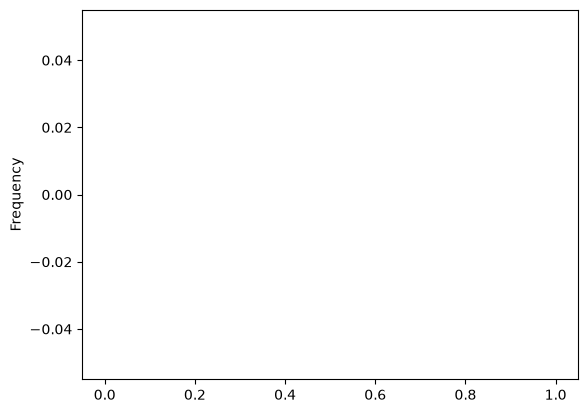

In [4]:
values.plot(kind="hist")
plt.show()

Read the first line as:

> Ask the `values` Series object to run its `plot()` method.

This is the same object-method pattern we saw with `df.head()` and `point_a.move()`.

## Histograms 

Histograms show distributions.  A distribution describes how numerical values are spread across their possible range.

A histogram groups values into intervals called bins and counts how many observations fall in each interval.

The following will show you how to make a basic histogram:

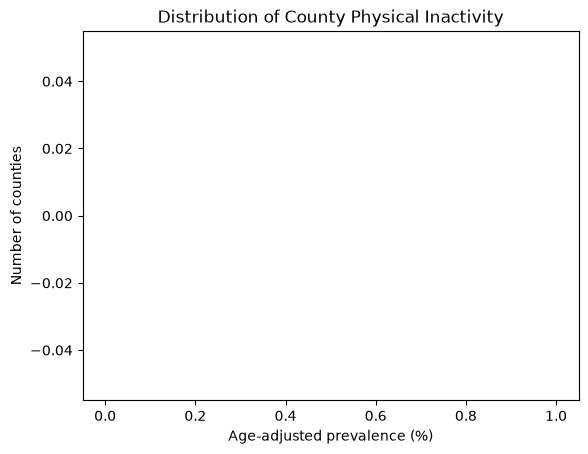

In [5]:
ax = analysis["Data_Value"].plot(
    kind="hist", ## this attribute is for making a histogram. Other options are line, bar, pie...
    bins=10 ## this is the number of bins, you might want to try a different number of bins
)

ax.set_title("Distribution of County Physical Inactivity") ## This will be the title
ax.set_xlabel("Age-adjusted prevalence (%)") ## This will be the label on the x axis
ax.set_ylabel("Number of counties")## This will be the label on the y axis

plt.show() 

### Notice the `ax` object

The plotting method returns a Matplotlib Axes object:

```python
ax = analysis["Data_Value"].plot(...)
```

Then we call methods belonging to that object:

```python
ax.set_title(...)
ax.set_xlabel(...)
ax.set_ylabel(...)
```



In [6]:
type(ax)

matplotlib.axes._axes.Axes

### Practice 1  

For each expression, identify the object and the method:

```python
analysis["Data_Value"].plot(kind="hist")
ax.set_title("Distribution")
plt.show()
```

Note: `plt` is a module alias, so `plt.show()` is a function accessed from the Matplotlib plotting module. The dot still means "get something from the thing before the dot", but that  "thing" isn't necessarily an object: it could be a Python module (or submodule).

## Mean, Median, and Distribution

Before looking at the histogram, calculate two measures of its center.

In [7]:
mean_value = analysis["Data_Value"].mean()
median_value = analysis["Data_Value"].median()

print("Mean:", mean_value)
print("Median:", median_value)

Mean: nan
Median: nan


### Discussion

- Are the mean and median close together?
- Is the distribution roughly symmetric or does it appear skewed?
- Are there counties far from the center of the distribution?



Let's see what we learn by examining a histogram of population.

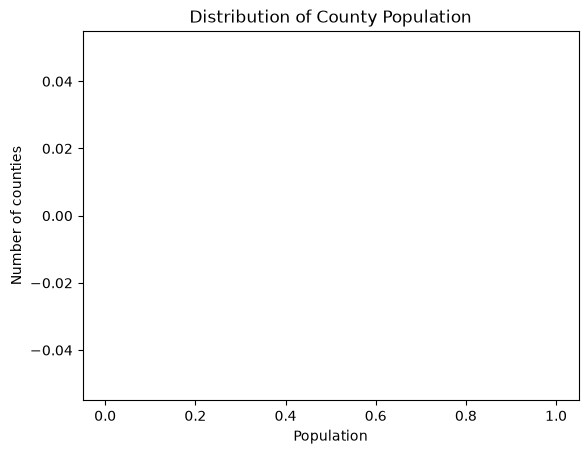

In [8]:
ax = analysis["TotalPopulation"].plot(
    kind="hist",
    bins=10
)

ax.set_title("Distribution of County Population")
ax.set_xlabel("Population")
ax.set_ylabel("Number of counties")

plt.show()

In [30]:
print("Population min   :", analysis["TotalPopulation"].min())
print("Population max   :", analysis["TotalPopulation"].max())
print("Population mean  :", int(analysis["TotalPopulation"].mean()))
print("Population median:", int(analysis["TotalPopulation"].median()))

Population min   : nan
Population max   : nan


ValueError: cannot convert float NaN to integer

### Discussion

Compare the population histogram with the physical inactivity histogram.

Which distribution would be more difficult to represent with equal-width classes? Why?

## Use bar charts for numeric data grouped in categories
Histograms show distributions. Bar charts are better when we want to compare specific categories or named observations.

Let's examine the ten counties with the highest physical inactivity values.

In [ ]:
top10 = analysis.sort_values(
    "Data_Value",
    ascending=False
).head(10)

top10[["LocationName", "Data_Value"]]

,LocationName,Data_Value
49,Robeson,34.9
30,Halifax,33.1
89,Scotland,32.7
60,Lenoir,32.3
47,Washington,32.0
18,Bertie,31.8
6,Anson,31.7
38,Edgecombe,31.7
61,Hertford,31.6
41,Greene,31.6


In [31]:
ax = top10.plot(
    kind="barh",
    x="LocationName",
    y="Data_Value",
    legend=False
)

ax.set_title("Ten Highest County Physical Inactivity Values")
ax.set_xlabel("Age-adjusted prevalence (%)")
ax.set_ylabel("County")

plt.show()

NameError: name 'top10' is not defined

### choosing histograms vs. bar charts

- **Histogram:** distribution of one numeric variable: data where you might want to look at the plot and estimate the average value, or see whether there are 'long tails.'
- **Bar chart:** values grouped into categories.  You may want to compare categ

Choose based on the question you want the visualization to answer.

## Scatterplot — Relationship Between Two Numeric Variables

A scatterplot is useful when each row has two numerical measurements and we want to examine their relationship.

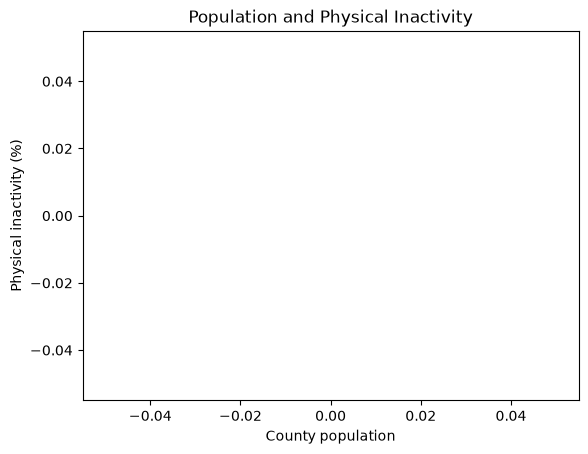

In [32]:
ax = analysis.plot(
    kind="scatter",
    x="TotalPopulation",
    y="Data_Value"
)

ax.set_title("Population and Physical Inactivity")
ax.set_xlabel("County population")
ax.set_ylabel("Physical inactivity (%)")

plt.show()

### Discussion

Does county population appear strongly related to physical inactivity in this dataset?

The purpose here is not to claim causation. The scatterplot helps us inspect whether a visible relationship exists.

## Classification — Turning Continuous Values into Classes

Good map design often uses a limited number of colors rather than a unique color for every numerical value.

That means continuous values must be placed into classes.

Today we will compare two classification rules using pandas:

1. **Equal interval** — each class covers the same numeric width.
2. **Quantile** — each class contains approximately the same number of observations.

Later in the cartography part of the course we will add **natural breaks (Jenks)**, which places class breaks around clusters and gaps in the data.

## Equal Interval Classification

`pd.cut()` can divide the numerical range into equal-width intervals.

In [33]:
## but before understanding what we do in the next section, you need to remember that functions can return more than one value
## take this example
## this a function that retuns a tuple with two values. 
def calculate_numbers(number):
    doubled = number * 2
    tripled = number * 3

    return doubled, tripled

##  when I call the function, I can assign those values to two variables

result1, result2 = calculate_numbers(5)

print(result1)  # 10
print(result2)  # 15



10
15


In [34]:
## here we are going to use the pd.cut method
equal_class, equal_breaks = pd.cut(
    analysis["Data_Value"],
    bins=5,
    include_lowest=True,
    retbins=True
)

analysis["EqualInterval"] = equal_class

print("Equal interval breaks:")
print(equal_breaks)
print('length:', len(equal_class)) ## notice that it has the same length as the table, that is how it was possible to assign it as a column to the table.
analysis.head(3) ## notice that now we have a column named EqualInterval

ValueError: Cannot cut empty array

In [35]:
## Using value counts to see how many counties are withing each class
analysis["EqualInterval"].value_counts().sort_index()

KeyError: 'EqualInterval'

### Question

Do all five classes contain the same number of counties?

> They should **not** necessarily contain the same number because equal interval controls the **width of the numeric ranges**, not the number of observations.

## Quantile Classification

`pd.qcut()` creates classes containing approximately equal numbers of observations.

In [ ]:
quantile_class, quantile_breaks = pd.qcut(
    analysis["Data_Value"],
    q=5,
    retbins=True,
    duplicates="drop"
)

analysis["Quantile"] = quantile_class

print("Quantile breaks:")
print(quantile_breaks)
analysis.head(3) ## notice that now we have a column named Quantile

Quantile breaks:
[17.9  21.68 24.06 26.28 28.7  34.9 ]


,LocationName,Data_Value,TotalPopulation,EqualInterval,Quantile
1,Cleveland,26.2,101378,"(24.7, 28.1]","(24.06, 26.28]"
2,Burke,26.7,88338,"(24.7, 28.1]","(26.28, 28.7]"
3,Alamance,23.7,179165,"(21.3, 24.7]","(21.68, 24.06]"


In [ ]:
analysis["Quantile"].value_counts().sort_index()

Quantile
(17.898999999999997, 21.68]    20
(21.68, 24.06]                 20
(24.06, 26.28]                 20
(26.28, 28.7]                  20
(28.7, 34.9]                   20
Name: count, dtype: int64

### Question

Why are the class counts more balanced under quantiles?

What did the method have to change in order to make the counts more balanced?

## Compare the Classification Breaks

Put the break values side by side conceptually:

```text
Equal interval: classes have equal numeric widths
Quantile:       classes have similar numbers of counties
```

There is no universally "correct" classification. The choice changes how differences are communicated.

## Visualize the Two Classification Results

Because we have not introduced GeoPandas yet, we will visualize the classes as sorted values rather than a map.

Each point is one county. The vertical position simply separates the counties; the horizontal position is the physical inactivity value. Color represents the class assigned by the classification rule.

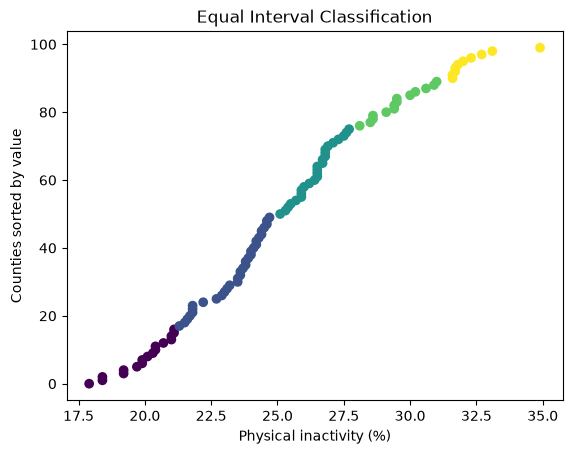

In [ ]:
equal_sorted = analysis.sort_values("Data_Value").copy()

equal_codes = equal_sorted["EqualInterval"].cat.codes 
## cat.codes converts the categories in a pandas categorical column into integer codes

fig, ax = plt.subplots()
ax.scatter(
    equal_sorted["Data_Value"], ## the x 
    range(len(equal_sorted)), ## the y 
    c=equal_codes, ## assigning a class
    cmap="viridis" ## assign a the viridi color ramp by class
)

ax.set_title("Equal Interval Classification")
ax.set_xlabel("Physical inactivity (%)")
ax.set_ylabel("Counties sorted by value")

plt.show()

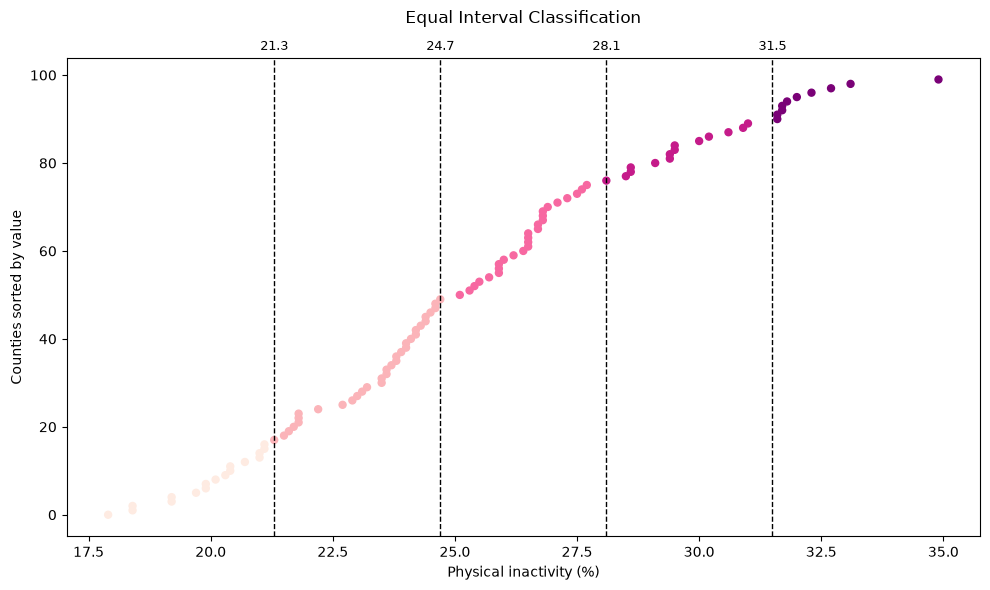

In [ ]:
## making a fancier plot

from matplotlib.colors import ListedColormap

colors = [ ## color ramp obtained from ColorBrewer
    "#feebe2",
    "#fbb4b9",
    "#f768a1",
    "#c51b8a",
    "#7a0177"
]

color_map = ListedColormap(colors) ## make a color ramp

equal_sorted = analysis.sort_values("Data_Value").copy()
equal_codes = equal_sorted["EqualInterval"].cat.codes

fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(
    equal_sorted["Data_Value"],
    range(len(equal_sorted)),
    c=equal_codes,
    cmap=color_map,
    s=25 ## size of the dot
)

# Get the internal boundaries between classes
categories = equal_sorted["EqualInterval"].cat.categories
class_breaks = equal_breaks[1:-1] ## slicing the list to get the class breaks


# Making a loop that will draw a vertical line and add a label for each class boundary
for value in class_breaks:
    ax.axvline(
        x=value,
        color="black",
        linestyle="--",
        linewidth=1
    )

    ax.text(
        value,
        1.01,
        f"{value:.1f}",
        transform=ax.get_xaxis_transform(),
        ha="center",
        va="bottom",
        fontsize=9
    )

ax.set_title("Equal Interval Classification", pad=25)
ax.set_xlabel("Physical inactivity (%)")
ax.set_ylabel("Counties sorted by value")

plt.tight_layout()
plt.show()

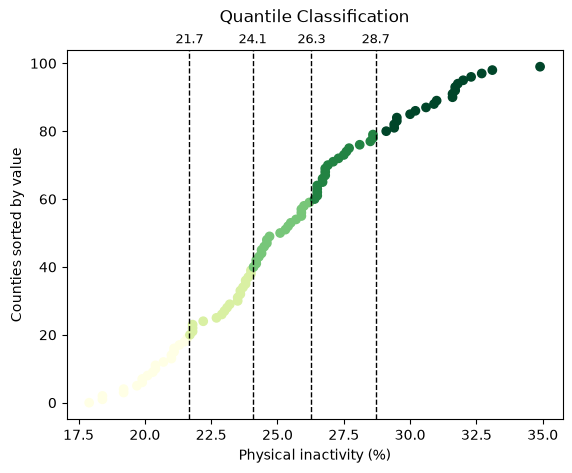

In [ ]:
quantile_sorted = analysis.sort_values("Data_Value").copy()

quantile_codes = quantile_sorted["Quantile"].cat.codes

fig, ax = plt.subplots()
ax.scatter(
    quantile_sorted["Data_Value"],
    range(len(quantile_sorted)),
    c=quantile_codes,
    cmap="YlGn"
)

class_breaks = quantile_breaks[1:-1] ## slicing the list to get the class breaks


# Making a loop that will draw a vertical line and add a label for each class boundary
for value in class_breaks:
    ax.axvline(
        x=value,
        color="black",
        linestyle="--",
        linewidth=1
    )

    ax.text(
        value,
        1.01,
        f"{value:.1f}",
        transform=ax.get_xaxis_transform(),
        ha="center",
        va="bottom",
        fontsize=9
    )


ax.set_title("Quantile Classification",pad=20) 
ax.set_xlabel("Physical inactivity (%)")
ax.set_ylabel("Counties sorted by value")

plt.show()

### Discussion — Same data, different story

Compare the two plots.

- Which method places similar numerical values into different classes more often?
- Which method creates classes with very different numbers of counties?
- If these classes were represented with five map colors, how might the visual impression change?

This is the idea we will revisit when we make choropleth maps with GeoPandas.